# Fama‑French Factor Analysis

### Interpreting the regression summary:

Alpha- average excess return not explained by factors (high p-value means highly explainable by factors)

Betas- sensitivities to each factors (tells you which variables most explain)

R^2- how much of the stock's excess return variance is explained by the model (high R^2 means factors explain stock well and model is good)

Rolling betas- show how a stock might become more growth-like or value-like over time

Rolling R^2- tells whether factors are more/less explanatory in different regimes

ADF p-value- low p-value means residuals are stationary (good for OLS assumptions)

Ljung-box p-value- low p-value means residuals show autocorrelation (model might be misspecified and should consider adding lags or GARCH)

### Fama–French 3- and 5-factor data

Mkt-RF (Market Risk Premium)- excess return of the market over the risk-free rate (Market return - RF). 
Captures exposure to general market risk. A higher value means higher market exposure.

SMB (Small - Big)- return of small-cap stocks minus large-cap stocks. 
Measures size effect. If postive, the stock behaves more like a small-cap.

HML (High B/M (value stock)- Low B/M (growth stock))- B/M means book-to-market. Measures value effect. Positive values mean exposure to value stocks; negative values mean exposure to growth stocks.

RMW (Robust - Weak)- Return of firms with robust (high) profitability - those with weak profits. Captures exposure to profitability. Positive means more profitable bias.

CMA (Conservative - Aggressive)- Return of firms with conservative investment vs. aggressive investors. Captures investment behavior. Postive means preference for firms that reinvest less.

RF (Risk-Free Rate)- The return of a risk-free asset. Used to compute excess returns: Actual Stock Returns - RF = excess returns.

## Code for Analyzing One Stock

In [ ]:
# Configurations

CONFIG = {
    "ticker": "AAPL",            # stock to analyze
    "start": "2005-01-01",       # start date for price data
    "end": "2025-07-25",         # end date
    "ff_model": 5,                 # 3 or 5 (number of Fama-French factors)
    "rolling_window_months": 36,   # rolling regression window length (in months)
    "rf_annual": 0.04,             # only used if you want to compare with an annual RF elsewhere
    "make_plots": True,
}

[*********************100%***********************]  1 of 1 completed

=== Fama-French Factor Analysis ===
Ticker: AAPL
Model : FF5

=== OLS Summary ===
                            OLS Regression Results                            
Dep. Variable:                 Excess   R-squared:                       0.590
Model:                            OLS   Adj. R-squared:                  0.552
Method:                 Least Squares   F-statistic:                     15.27
Date:                Sat, 26 Jul 2025   Prob (F-statistic):           2.78e-09
Time:                        19:31:37   Log-Likelihood:                 91.924
No. Observations:                  59   AIC:                            -171.8
Df Residuals:                      53   BIC:                            -159.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------

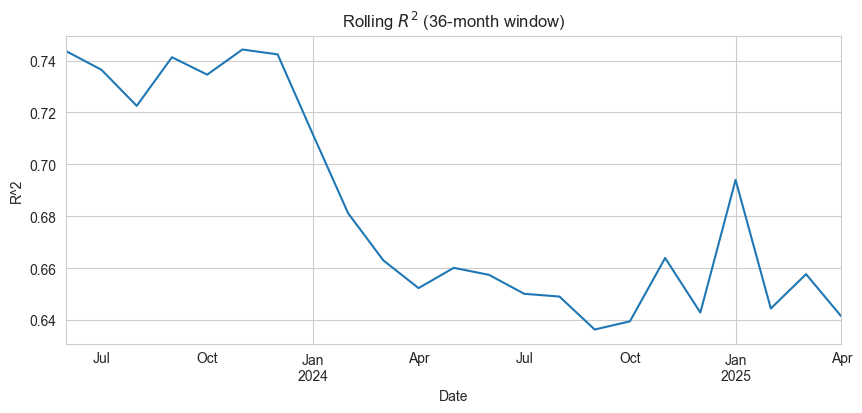

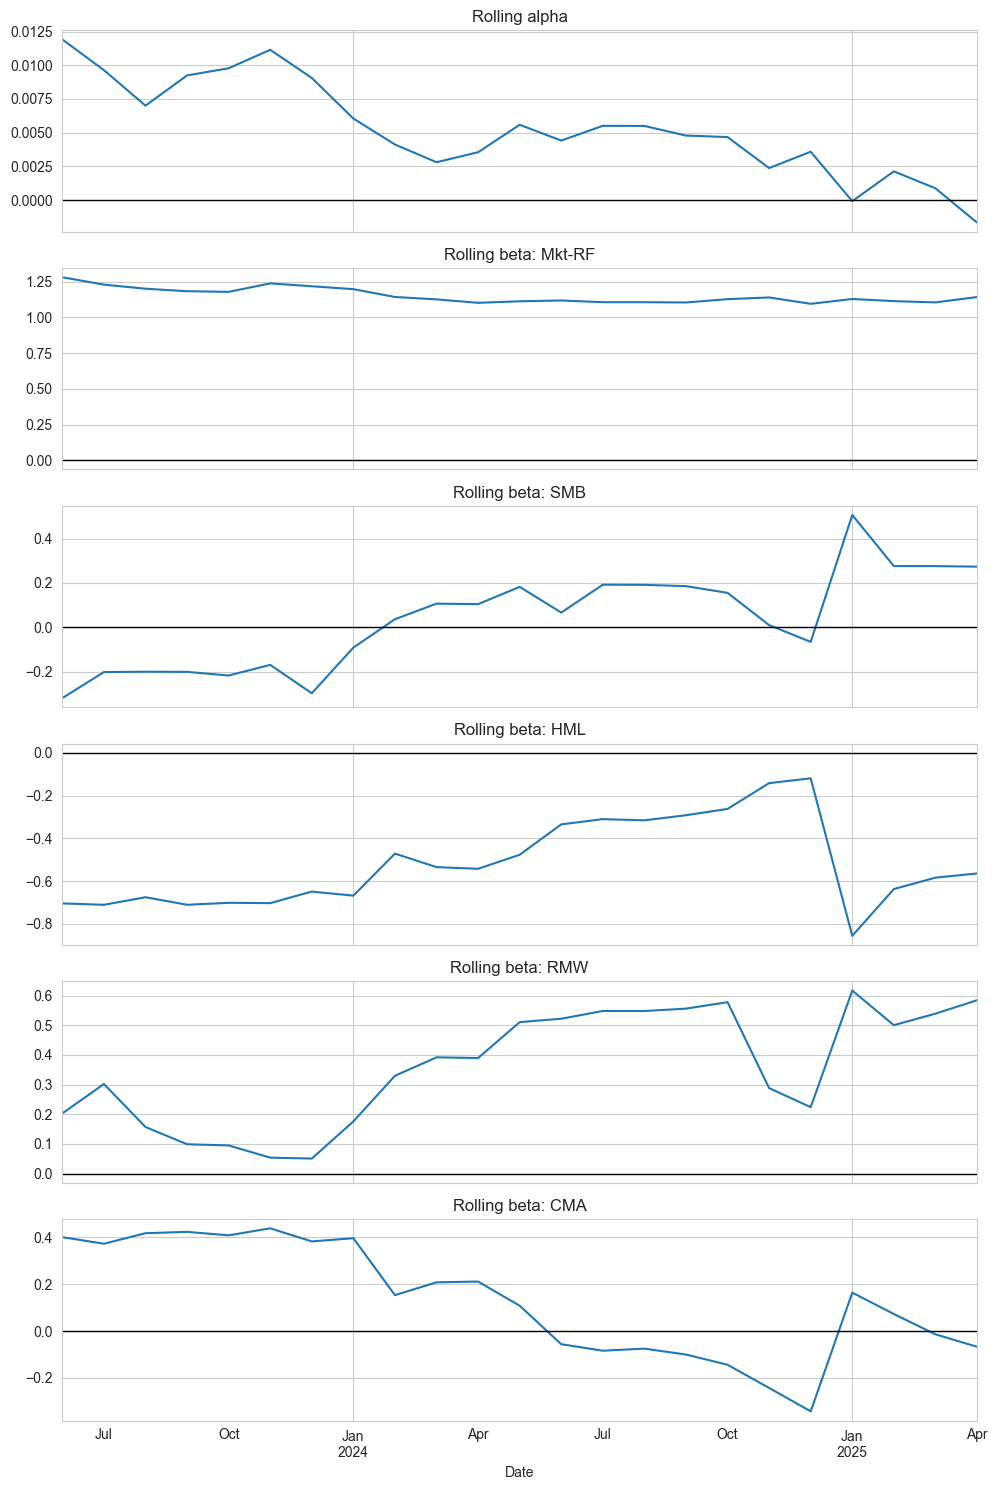

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller

from pandas_datareader import data as web

# ======================
# 2) Data loaders
# ======================
def load_prices_monthly(ticker: str, start: str, end: str) -> pd.Series:
    """Download daily prices with yfinance, convert to month-end prices, return monthly returns."""
    px = yf.download(ticker, start=start, end=end, auto_adjust=True)["Close"].dropna()
    monthly_px = px.resample('M').last()
    rets = monthly_px.pct_change().dropna()
    rets.name = ticker
    return rets


def load_fama_french_factors(model: int = 3) -> pd.DataFrame:
    """Load Fama-French monthly factors (3 or 5 factors) as a DataFrame with datetime index.
    Returns factors in decimal form (not %) and Rf as a column named 'RF'."""
    if model not in (3, 5):
        raise ValueError("model must be 3 or 5")

    if model == 3:
        ff = web.DataReader('F-F_Research_Data_Factors', 'famafrench')[0]
        # Columns: ['Mkt-RF', 'SMB', 'HML', 'RF']
    else:
        ff = web.DataReader('F-F_Research_Data_5_Factors_2x3', 'famafrench')[0]
        # Columns: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']

    ff.index = pd.to_datetime(ff.index.to_timestamp("M"))  # end of month
    ff = ff / 100.0  # convert % to decimal
    return ff

# ======================
# 3) Regression helpers
# ======================
def prepare_regression_data(stock_rets: pd.Series, ff: pd.DataFrame, model: int) -> pd.DataFrame:
    """Align stock returns with FF factors, compute excess returns."""
    df = pd.concat([stock_rets, ff], axis=1).dropna()
    # Excess return of the stock
    df['Excess'] = df[stock_rets.name] - df['RF']

    if model == 3:
        X_cols = ['Mkt-RF', 'SMB', 'HML']
    else:
        X_cols = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']

    y = df['Excess']
    X = df[X_cols]
    X = sm.add_constant(X)  # add alpha
    return df, X_cols, X, y


def run_ff_regression(X, y):
    """Run OLS regression and return the fitted model and summary stats."""
    model = sm.OLS(y, X, missing='drop').fit()
    return model


def rolling_regressions(df: pd.DataFrame, model: int, window: int):
    """Run rolling regressions to estimate time-varying betas and R^2."""
    if model == 3:
        X_cols = ['Mkt-RF', 'SMB', 'HML']
    else:
        X_cols = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']

    betas = []
    r2s = []
    idx = []

    for i in range(window, len(df)):
        sub = df.iloc[i-window:i]
        y = sub['Excess']
        X = sm.add_constant(sub[X_cols])
        res = sm.OLS(y, X).fit()
        idx.append(sub.index[-1])
        # store coefficients in the same order
        coefs = [res.params.get('const', np.nan)] + [res.params.get(col, np.nan) for col in X_cols]
        betas.append(coefs)
        r2s.append(res.rsquared)

    coef_cols = ['alpha'] + X_cols
    betas_df = pd.DataFrame(betas, columns=coef_cols, index=idx)
    r2s = pd.Series(r2s, index=idx, name='R2')
    return betas_df, r2s

# ======================
# 4) Time-series diagnostics (optional)
# ======================
def adf_test(series: pd.Series):
    stat, p, lags, nobs, crit, icbest = adfuller(series.dropna(), autolag='AIC')
    return {
        'adf_stat': stat,
        'pvalue': p,
        'lags': lags,
        'nobs': nobs,
        'crit_values': crit,
    }


def ljung_box_test(series: pd.Series, lags: int = 12):
    lb = acorr_ljungbox(series.dropna(), lags=[lags], return_df=True)
    return lb.iloc[0].to_dict()

# ======================
# 5) Main flow
# ======================
def main(cfg):
    print("=== Fama-French Factor Analysis ===")
    print(f"Ticker: {cfg['ticker']}")
    print(f"Model : FF{cfg['ff_model']}")

    # 1) Load data
    stock_rets = load_prices_monthly(cfg['ticker'], cfg['start'], cfg['end'])
    ff = load_fama_french_factors(cfg['ff_model'])

    # 2) Prepare data
    df, X_cols, X, y = prepare_regression_data(stock_rets, ff, cfg['ff_model'])

    # 3) Run regression
    res = run_ff_regression(X, y)

    # 4) Print results
    print("\n=== OLS Summary ===")
    print(res.summary())

    print("\n=== Key Metrics ===")
    print(f"Alpha (monthly): {res.params['const']:.4%}")
    print(f"Annualized alpha: {( (1+res.params['const'])**12 - 1 ):.4%}")
    print(f"R^2: {res.rsquared:.4f}")

    # 5) Rolling betas
    betas_df, r2s = rolling_regressions(df, cfg['ff_model'], cfg['rolling_window_months'])

    # 6) Time-series diagnostics on residuals
    resid = res.resid
    adf_res = adf_test(resid)
    lb_res = ljung_box_test(resid)

    print("\n=== Residual diagnostics ===")
    print(f"ADF p-value (stationarity): {adf_res['pvalue']:.4f}")
    print(f"Ljung-Box p-value (AC up to lag 12): {lb_res['lb_pvalue']:.4f}")

    # 7) Plots
    if cfg["make_plots"]:
        sns.set_style("whitegrid")

        # Rolling R2
        plt.figure(figsize=(10, 4))
        r2s.plot()
        plt.title(f"Rolling $R^2$ ({cfg['rolling_window_months']}-month window)")
        plt.ylabel("R^2")
        plt.xlabel("Date") 
        plt.show()

        # Rolling betas (factors only)
        fig, axes = plt.subplots(len(X_cols) + 1, 1, figsize=(10, 2.5 * (len(X_cols) + 1)), sharex=True)
        
        betas_df['alpha'].plot(ax=axes[0])
        axes[0].set_title("Rolling alpha")
        axes[0].axhline(0, color='k', lw=1)

        for i, col in enumerate(X_cols, start=1):
            betas_df[col].plot(ax=axes[i])
            axes[i].set_title(f"Rolling beta: {col}")
            axes[i].axhline(0, color='k', lw=1)

        axes[-1].set_xlabel("Date")  

        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    main(CONFIG)

## Code for Analyzing Multiple Stocks

In [16]:
# Configuration
tickers = ["AAPL", "MSFT", "META"]
start_date = "2018-01-01"
end_date = "2024-12-31"
rolling_window_months = 12
window_size = rolling_window_months * 21  # Approx 21 trading days/month

[*********************100%***********************]  1 of 1 completed

Processing AAPL...



[*********************100%***********************]  1 of 1 completed

Processing MSFT...



[*********************100%***********************]  1 of 1 completed

Processing META...


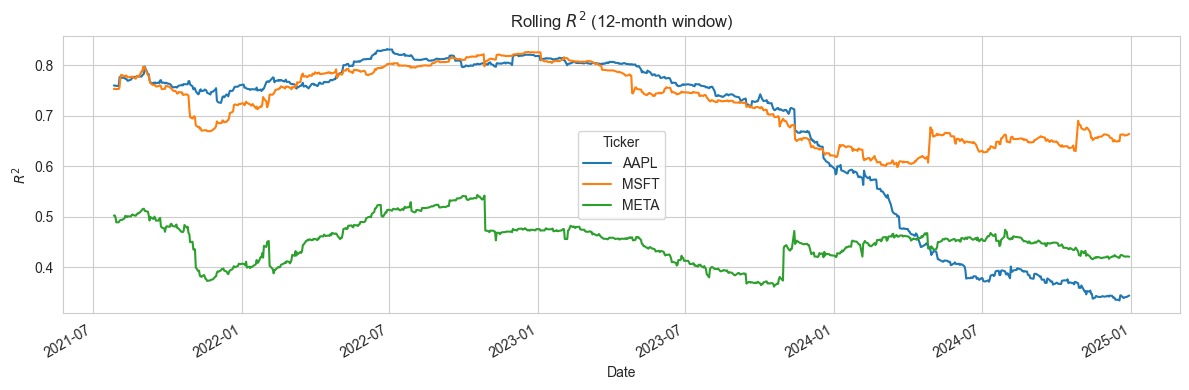

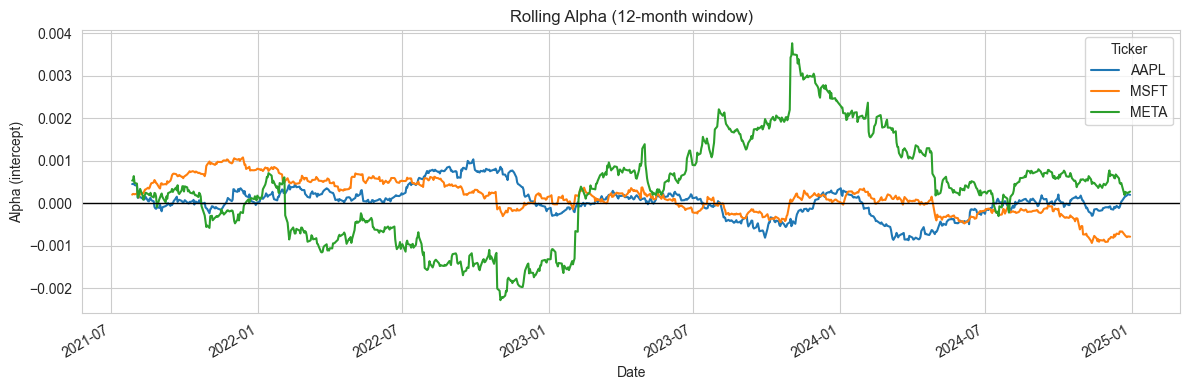

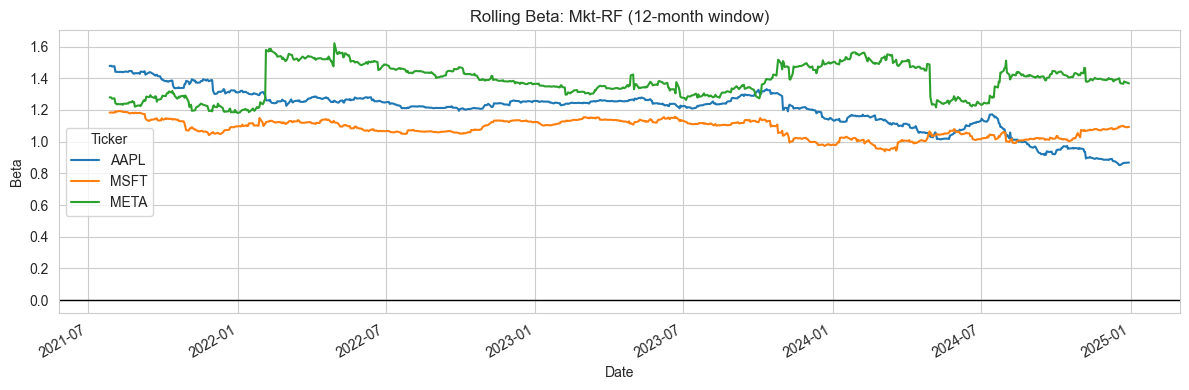

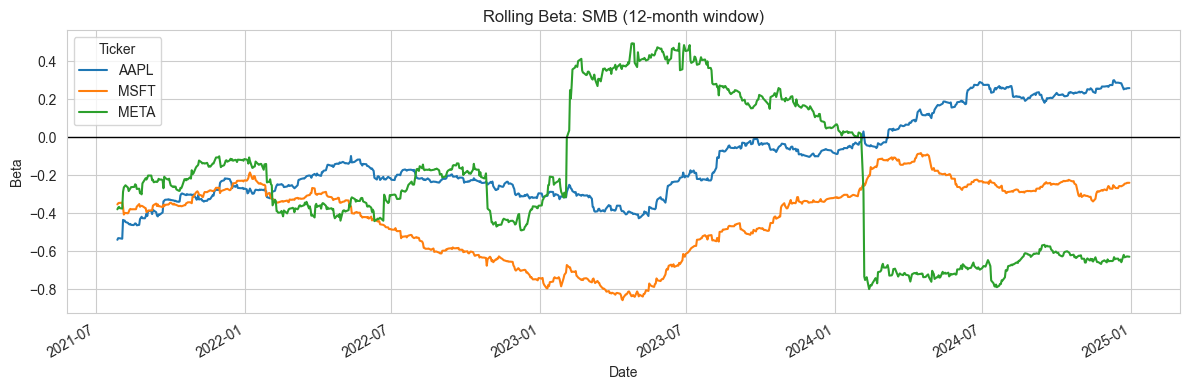

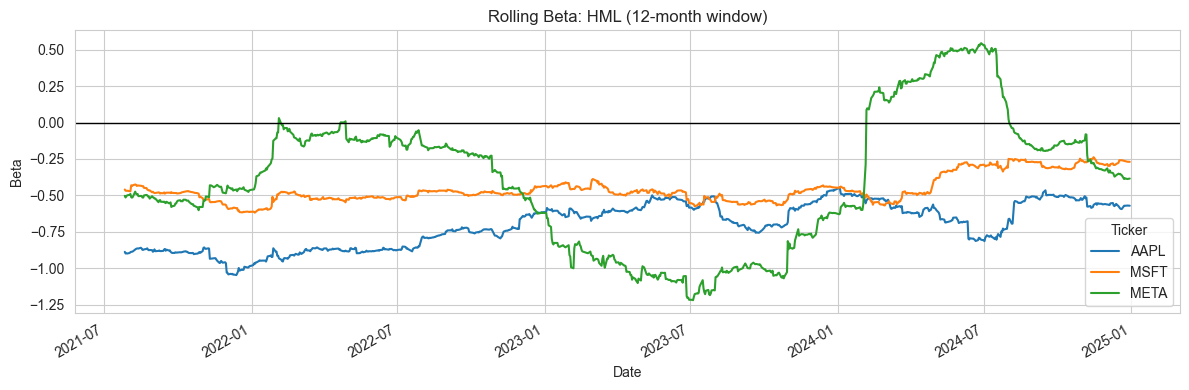

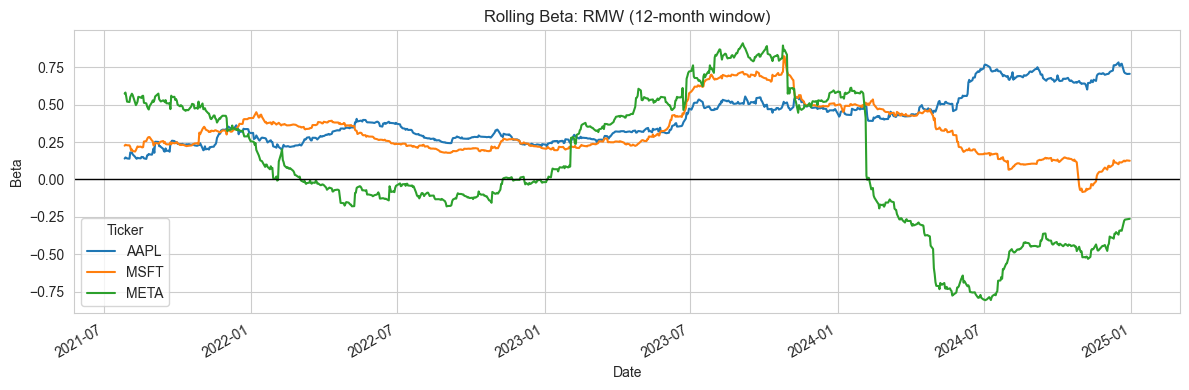

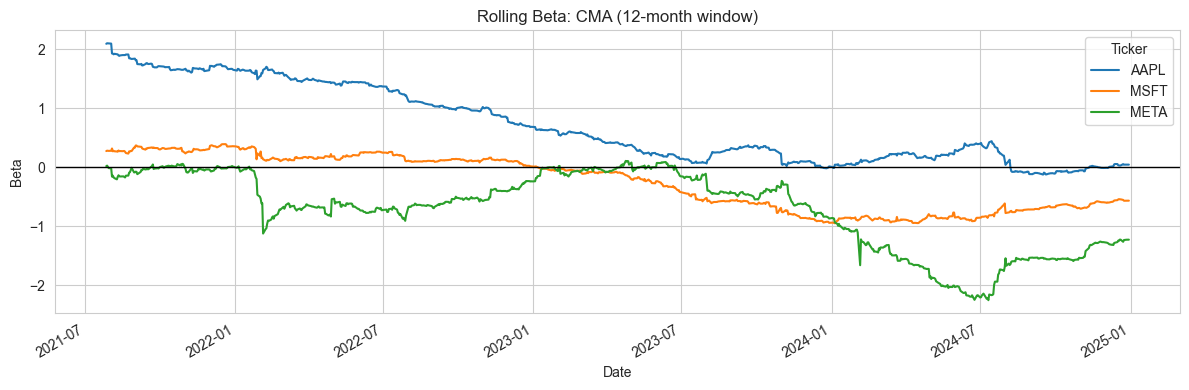

In [23]:
import pandas_datareader.data as web
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# -----------------------------
# Fama-French Data
# -----------------------------
ff_data = web.DataReader("F-F_Research_Data_5_Factors_2x3_daily", "famafrench")[0]
ff_data.index = pd.to_datetime(ff_data.index)
ff_data.columns = ff_data.columns.str.strip()  # Strip any whitespace
ff = ff_data.loc[start_date:end_date] / 100  # Convert % to decimals
ff = ff[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']]

# -----------------------------
# Storage for all tickers
# -----------------------------
r2s_all = pd.DataFrame()
alphas_all = pd.DataFrame()
betas_all = {factor: pd.DataFrame() for factor in ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']}

# -----------------------------
# Loop over each ticker
# -----------------------------
for ticker in tickers:
    print(f"Processing {ticker}...")

    stock = yf.download(ticker, start=start_date, end=end_date)['Close']
    if stock.isna().all().all() or len(stock) < 2:
        print(f" -> No data for {ticker}, skipping.")
        continue

    stock_ret = stock.pct_change().dropna()
    # Make sure stock returns are named and datetime aligned
    stock_ret.columns = ['stock']
    stock_ret.index = pd.to_datetime(stock_ret.index)
    df = stock_ret.join(ff, how='inner')

    # Check if 'stock' column was retained
    if 'stock' not in df.columns:
        print(f" -> ERROR: 'stock' column missing after join for {ticker}. Skipping.")
        continue

    df = df.dropna()

    if df.empty or 'RF' not in df.columns:
        print(f" -> Skipping {ticker}: FF data not aligned or incomplete.")
        continue

    df['excess'] = df['stock'] - df['RF']

    X_cols = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']
    r2s, alphas = [], []
    betas = {col: [] for col in X_cols}
    index = []

    for i in range(window_size, len(df)):
        window = df.iloc[i - window_size:i]
        X = sm.add_constant(window[X_cols])
        y = window['excess']

        model = sm.OLS(y, X).fit()
        r2s.append(model.rsquared)
        alphas.append(model.params.get('const', np.nan))
        for col in X_cols:
            betas[col].append(model.params.get(col, np.nan))
        index.append(df.index[i])

    r2s_all[ticker] = pd.Series(r2s, index=index)
    alphas_all[ticker] = pd.Series(alphas, index=index)
    for col in X_cols:
        betas_all[col][ticker] = pd.Series(betas[col], index=index)

# -----------------------------
# Plotting
# -----------------------------

sns.set_style("whitegrid")

# Rolling R² plot
plt.figure(figsize=(12, 4))
r2s_all.plot(ax=plt.gca())
plt.title(f"Rolling $R^2$ ({rolling_window_months}-month window)")
plt.ylabel("$R^2$")
plt.xlabel("Date")
plt.legend(title="Ticker")
plt.tight_layout()
plt.show()

# Rolling Alpha plot (fixed)
plt.figure(figsize=(12, 4))
alphas_all.plot(ax=plt.gca())
plt.title(f"Rolling Alpha ({rolling_window_months}-month window)")
plt.ylabel("Alpha (intercept)")
plt.xlabel("Date")
plt.axhline(0, color="black", lw=1)
plt.legend(title="Ticker")
plt.tight_layout()
plt.show()

# Rolling Betas (for each factor, across all tickers)
for factor_name, beta_df in betas_all.items():
    plt.figure(figsize=(12, 4))
    beta_df.plot(ax=plt.gca())
    plt.title(f"Rolling Beta: {factor_name} ({rolling_window_months}-month window)")
    plt.ylabel("Beta")
    plt.xlabel("Date")
    plt.axhline(0, color="black", lw=1)
    plt.legend(title="Ticker")
    plt.tight_layout()
    plt.show()
